In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve

## Load Data

In [2]:
def read_fasta(path):
    headers, sequences = [], []
    h, buf = None, []
    
    with open(path, 'r') as f:
        for line in f:
            if not line: 
                continue
            if line[0] == '>':
                if h is not None:
                    sequences.append(''.join(buf).upper())
                    buf = []
                h = line[1:].strip()
                headers.append(h)
            else:
                buf.append(line.strip())
        if h is not None:
            sequences.append(''.join(buf).upper())
            
    return headers, sequences

def load_labels(path):
    label_dict = {}
    with open(path, 'r') as f:
        for line in f:
            if not line:
                continue
            parts = line.strip().split('\t')
            header = parts[0][1:]
            if parts[1] == "None":
                label = 0.0
            else:
                label = 1.0
            label_dict[header] = label
    return label_dict

## Data Processing

In [3]:
# mapping ACGT to 0123
# mapping acgt to 0123
# mapping N and others to 4

ENCODE = np.full(256, 4, dtype=np.int64)
for ch, idx in zip(b"ACGTacgt", [0, 1, 2, 3, 0, 1, 2, 3]):
    ENCODE[ch] = idx

# reverse complement ACGTN -> TGCAN -> 32104
REV_COMP = torch.tensor([3, 2, 1, 0, 4]) 

In [4]:
class SeqDataset(Dataset):
    def __init__(self, headers, sequences, labels):
        self.headers = headers
        self.sequences = sequences
        self.labels = np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.headers[idx], self.sequences[idx].encode('ascii', 'ignore'), self.labels[idx]

In [5]:
def collate_pad(batch):
    headers, seq_bytes, labels = zip(*batch)
    idx_list = [ENCODE[np.frombuffer(sb, dtype=np.uint8)] for sb in seq_bytes]
    max_length = max(x.size for x in idx_list)
    batch_size = len(idx_list)
    
    X = torch.zeros(batch_size, 5, max_length, dtype=torch.float32)   # channels: A, C, G, T, N
    mask = torch.zeros(batch_size, max_length, dtype=torch.bool)      # padding mask
    
    for i, idx_np in enumerate(idx_list):
        length = idx_np.size
        idx = torch.from_numpy(idx_np).long()
        X[i, idx, torch.arange(length)] = 1.0
        mask[i, :length] = (idx != 4)   # invalid positions: N or everything beyond the length
    
    Y = torch.tensor(labels, dtype=torch.float32)
    return headers, X, mask, Y

## CNN Network

In [6]:
# Reverse complement convolution layer
# input: one-hot (B, 5, L)
# output: RC-invariant feature map (B, C, L)

def rc_kernel(k: torch.Tensor):
    # Reverse complement the convolution kernel
    # k: (out_channels, in_channels, length)
    k_flip = k.flip(-1)
    return k_flip.index_select(1, REV_COMP.to(k.device))

class RCFirstConv1d(nn.Module):
    
    def __init__(self, out_channels, kernel_size=15, dilation=1, bias=True, dropout=0.1):
        super().__init__()
        assert kernel_size % 2 == 1
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(5, out_channels, kernel_size, padding=pad, dilation=dilation, bias=bias)
        self.batch_norm = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        
        y1 = self.conv(x)                    # (B, C, L)
        weight = self.conv.weight            # (C_out, 5, K)
        b = self.conv.bias
        
        weight_rc = rc_kernel(weight)        # (C_out, 5, K)
        y2 = F.conv1d(x, weight_rc, None, stride=1, padding=self.conv.padding[0], dilation=self.conv.dilation[0])
        y2 = y2.flip(-1)
        if b is not None:
            y1 = y1 + b.view(1, -1, 1)
            y2 = y2 + b.view(1, -1, 1)

        y = 0.5 * (y1 + y2)                  # RC-invariant feature map
        y = self.dropout(F.gelu(self.batch_norm(y)))
        return y 

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, kernel_size=9, dilation=1, dropout=0.1):
        super().__init__()
        pad = (kernel_size // 2) * dilation
        self.conv = nn.Conv1d(c_in, c_out, kernel_size, padding=pad, dilation=dilation)
        self.batch_norm = nn.BatchNorm1d(c_out)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        return self.dropout(F.gelu(self.batch_norm(self.conv(x))))

class MaskedMaxPool1d(nn.Module):
    def __init__(self, kernel_size=2, stride=2):
        super().__init__()
        self.kernel_size, self.stride = kernel_size, stride

    def forward(self, x, mask):  # x:(B, C, L), mask:(B, L)
        m = mask.unsqueeze(1)
        x_masked = x.masked_fill(~m, float('-inf'))
        y = F.max_pool1d(x_masked, self.kernel_size, self.stride)
        m_pooled = F.max_pool1d(m.float(), self.kernel_size, self.stride) > 0
        y = y.masked_fill(~m_pooled, 0.0)
        return y, m_pooled.squeeze(1)


In [8]:
class RCInputInvariantCNN(nn.Module):
    def __init__(self, width=128, blocks=4, dilate=True, branches=2):
        super().__init__()
        self.first = RCFirstConv1d(width, kernel_size=15, dilation=1, dropout=0.1)
        self.branches = nn.ModuleList()
        for _ in range(branches):
            layers = []
            for i in range(blocks):
                dilation = 2 ** i if dilate else 1
                layers += [
                    ConvBlock(width, width, kernel_size=9, dilation=dilation),
                    ConvBlock(width, width, kernel_size=3, dilation=1),
                    MaskedMaxPool1d(kernel_size=2, stride=2)
                ]
            self.branches.append(nn.ModuleList(layers))
        self.head  = nn.Sequential(nn.Linear(width, 128), nn.GELU(), nn.Dropout(0.2), nn.Linear(128, 1))

    @staticmethod
    def masked_avg_pool(z, mask):
        if mask is None:
            return z.mean(-1)
        m = mask.unsqueeze(1).float()
        return (z * m).sum(-1) / m.sum(-1).clamp_min(1.0)

    @staticmethod
    def _run_branch(z, mask, layers):
        z_branch = z
        m_branch = mask.clone()
        for layer in layers:
            if isinstance(layer, MaskedMaxPool1d):
                z_branch, m_branch = layer(z_branch, m_branch)
            else:
                z_branch = layer(z_branch)
                z_branch = z_branch * m_branch.unsqueeze(1)
        return z_branch, m_branch

    def forward(self, x, mask=None):
        z0 = self.first(x)
        if mask is None:
            base_mask = torch.ones(z0.size(0), z0.size(-1), device=z0.device, dtype=torch.bool)
        else:
            base_mask = mask
        pooled = self.masked_avg_pool(z0, base_mask)
        for layers in self.branches:
            zb, mb = self._run_branch(z0, base_mask, layers)
            pooled = pooled + self.masked_avg_pool(zb, mb)
        return self.head(pooled).squeeze(1)

## Train & Eval

In [9]:
def resolve_device(requested=None):
    """Return the best available accelerator as a torch.device."""
    if requested is not None:
        return torch.device(requested)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

In [10]:
with torch.no_grad():
    device = resolve_device()
    model = RCInputInvariantCNN(width=16, blocks=2, dilate=False).to(device)
    X = torch.randn(3, 5, 128, device=device)
    mask = torch.zeros(3, 128, dtype=torch.bool, device=device)
    mask[0, :120] = True
    mask[1, :100] = True
    mask[2, :80] = True
    out = model(X, mask)
    print('Device:', device)
    print('Output shape:', out.shape)

Device: mps
Output shape: torch.Size([3])


In [21]:
def save_torch(data, path, filename): 
    os.makedirs(path, exist_ok=True)
    if os.path.exists("%s/%s.pt"%(path, filename)):
        n = 1
        while n <= 100:
            if os.path.exists("%s/%s%s.pt"%(path, filename, n)):
                n += 1
            else:
                torch.save(data, "%s/%s%s.pt"%(path, filename, n))
                break
    else:
        torch.save(data, "%s/%s.pt"%(path, filename))

In [ ]:
def run_train(fasta_path, label_path, batch_size=8, epochs=5, lr=1e-3, width=128, blocks=4, device=None, patience=5):
    device = resolve_device(device)
    print(f"Using device: {device}")

    headers, sequences = read_fasta(fasta_path)
    label_dict = load_labels(label_path)
    labels = [label_dict[h] for h in headers]

    idx_tr, idx_te = train_test_split(
        np.arange(len(sequences)), test_size=0.2, stratify=labels, random_state=42
    )
    ds_tr = SeqDataset([headers[i] for i in idx_tr], [sequences[i] for i in idx_tr], [labels[i] for i in idx_tr])
    ds_te = SeqDataset([headers[i] for i in idx_te], [sequences[i] for i in idx_te], [labels[i] for i in idx_te])

    loader_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=0, collate_fn=collate_pad)
    loader_te = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0, collate_fn=collate_pad)

    model = RCInputInvariantCNN(width=width, blocks=blocks, dilate=True).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss()

    print("Starting training...")

    history = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_auprc": []}
    best_state, best_epoch = None, None
    best_metrics = {"auroc": -float("inf"), "auprc": float("nan"), "val_loss": float("inf")}
    best_scores, best_labels = None, None
    last_scores, last_labels = None, None
    last_val_loss = None
    last_auroc, last_auprc = None, None
    bad = 0

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0

        pbar = tqdm(loader_tr, desc=f"Epoch {ep}/{epochs}", leave=False)
        for _, X, mask, Y in pbar:
            X = X.to(device, dtype=torch.float32)
            mask = mask.to(device)
            Y = Y.to(device, dtype=torch.float32)

            logits = model(X, mask)
            loss = loss_fn(logits, Y)
            opt.zero_grad()
            loss.backward()
            opt.step()

            running += loss.item() * X.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = running / len(ds_tr)

        model.eval()
        val_running = 0.0
        Ps, Ys = [], []
        with torch.no_grad():
            for _, X, mask, Y in tqdm(loader_te, desc="Val", leave=False):
                X = X.to(device, dtype=torch.float32)
                mask = mask.to(device)
                Y = Y.to(device, dtype=torch.float32)
                logits = model(X, mask)
                loss = loss_fn(logits, Y)
                val_running += loss.item() * X.size(0)
                p = torch.sigmoid(logits).detach().cpu().numpy()
                Ps.append(p)
                Ys.append(Y.detach().cpu().numpy())
        Ps = np.concatenate(Ps) if Ps else np.array([])
        Ys = np.concatenate(Ys) if Ys else np.array([])
        val_loss = val_running / len(ds_te) if len(ds_te) else float("nan")
        try:
            auroc = roc_auc_score(Ys, Ps)
            auprc = average_precision_score(Ys, Ps)
        except ValueError:
            auroc, auprc = float("nan"), float("nan")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auroc"].append(auroc)
        history["val_auprc"].append(auprc)

        print(f"Epoch {ep}: train loss {train_loss:.4f} | Val loss {val_loss:.4f} | Val AUROC {auroc:.4f} | AUPRC {auprc:.4f}")

        last_scores, last_labels = Ps, Ys
        last_val_loss, last_auroc, last_auprc = val_loss, auroc, auprc

        improved = auroc > best_metrics["auroc"] + 1e-4
        if improved:
            best_metrics = {"auroc": auroc, "auprc": auprc, "val_loss": val_loss}
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_scores, best_labels, best_epoch = Ps, Ys, ep
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("Early stopping.")
                break
        if auroc == 1:
            print("Early stopping.")
            break

    if best_state is not None:
        save_torch(best_state, "vgp_model_data_tpase", "rc_cnn_best")
        model.load_state_dict(best_state)
        model.to(device)
    else:
        best_scores, best_labels = last_scores, last_labels
        best_epoch = best_epoch if best_epoch is not None else len(history["train_loss"])
        best_metrics = {
            "auroc": last_auroc,
            "auprc": last_auprc,
            "val_loss": last_val_loss
        }

    results = {
        "model": model,
        "history": history,
        "metrics": {
            "best_epoch": best_epoch,
            "best_auroc": best_metrics["auroc"],
            "best_auprc": best_metrics["auprc"],
            "best_val_loss": best_metrics["val_loss"]
        },
        "roc": {
            "labels": best_labels,
            "scores": best_scores
        },
        "device": str(device)
    }
    return results

In [12]:
def plot_training_curves(history):
    epochs = np.arange(1, len(history.get("train_loss", [])) + 1)
    if len(epochs) == 0:
        raise ValueError("History is empty; run training first.")
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="Train loss", marker="o")
    axes[0].plot(epochs, history["val_loss"], label="Val loss", marker="o")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary cross-entropy")
    axes[0].set_title("Loss curves")
    axes[0].legend()
    axes[1].plot(epochs, history["val_auroc"], label="Val AUROC", marker="o")
    axes[1].plot(epochs, history["val_auprc"], label="Val AUPRC", marker="o")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Validation metrics")
    axes[1].legend()
    fig.tight_layout()
    return axes

def plot_roc(labels, scores):
    if labels is None or scores is None:
        raise ValueError("ROC data is missing; ensure training completed successfully.")
    fpr, tpr, _ = roc_curve(labels, scores)
    auc = roc_auc_score(labels, scores)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("Validation ROC curve")
    plt.legend(loc="lower right")
    plt.grid(True)

In [13]:
fasta_path = '../data/vgp/all_vgp_tes_2000.fa'
label_path = '../data/vgp/features-tpase.txt'

headers, sequences = read_fasta(fasta_path)
label_dict = load_labels(label_path)
labels = [label_dict[h] for h in headers]

In [14]:
# Long-running cell: executes full training
results = run_train(fasta_path, label_path, blocks=3, epochs=100, patience=10)

Using device: mps
Starting training...


Epoch 1/100:   0%|          | 0/200 [00:00<?, ?it/s]

Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1: train loss 0.2869 | Val loss 0.1757 | Val AUROC 0.9952 | AUPRC 0.9777


Epoch 2/100:   0%|          | 0/200 [00:00<?, ?it/s]

...

Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 16: train loss 0.0574 | Val loss 0.0635 | Val AUROC 0.9987 | AUPRC 0.9921


Epoch 17/100:   0%|          | 0/200 [00:00<?, ?it/s]

Val:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 17: train loss 0.0194 | Val loss 0.0169 | Val AUROC 1.0000 | AUPRC 1.0000
Early stopping.


array([<Axes: title={'center': 'Loss curves'}, xlabel='Epoch', ylabel='Binary cross-entropy'>,
       <Axes: title={'center': 'Validation metrics'}, xlabel='Epoch', ylabel='Score'>],
      dtype=object)

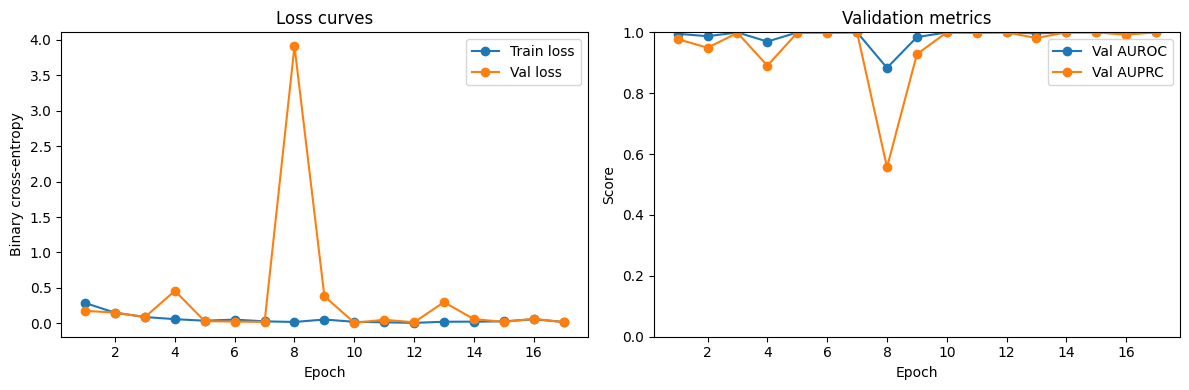

In [15]:
history = results["history"]
plot_training_curves(history)

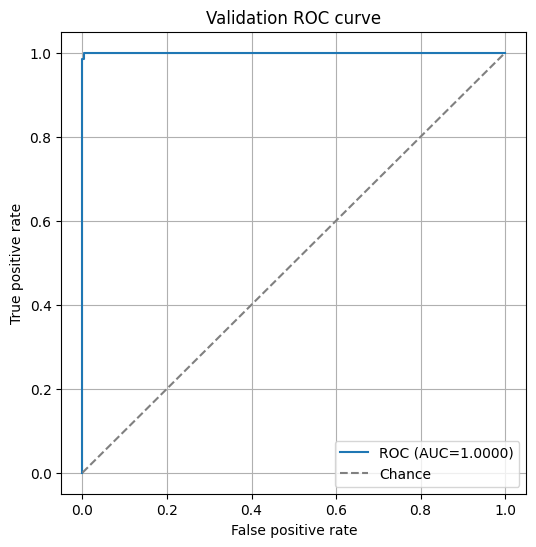

In [16]:
roc_data = results["roc"]
plot_roc(roc_data["labels"], roc_data["scores"])